In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from pprint import pp

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from utility.utils import data_distribution_frame, columns_with_null, DRMetrics, RepCompare

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA

np.random.seed(37)

In [2]:
data = pd.read_csv('../data/application_train.csv')

In [3]:
target = data['TARGET']
data.drop(columns=['TARGET'], inplace=True)

In [4]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.25, shuffle=True, stratify=target, random_state=37)

In [5]:
print(f'data_train = {data_train.shape}')
print(f'data_test = {data_test.shape}')
print(f'target_train = {target_train.shape}')
print(f'target_test = {target_test.shape}')

data_train = (230633, 121)
data_test = (76878, 121)
target_train = (230633,)
target_test = (76878,)


In [6]:
data_distribution_frame(target_train)

,value counts,percent of total
0,212014,92%
1,18619,8%


In [7]:
data_distribution_frame(target_test)

,value counts,percent of total
0,70672,92%
1,6206,8%


## Data Imputation, Scaling and Encoding

In [8]:
cat_columns = make_column_selector(dtype_include='object')(data_train)
num_columns = make_column_selector(dtype_exclude='object')(data_train)

In [9]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'), 
    OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist', min_frequency=1)
)
cat_pipeline

,steps,"[('simpleimputer', ...), ('onehotencoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [10]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'), RobustScaler()
)
num_pipeline

,steps,"[('simpleimputer', ...), ('robustscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


In [11]:
preprocessing = ColumnTransformer(transformers=[
    ('nums', num_pipeline, num_columns),
    ('cat_ohe', cat_pipeline, cat_columns),
], remainder='passthrough', n_jobs=-1)
preprocessing

,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [12]:
processed_data = preprocessing.fit_transform(data_train)

In [13]:
processed_data.shape

(230633, 245)

## Dimensionality Reduction

In [14]:
dr = DRMetrics(
    n_neighbors=12,
    isomap_fit_sample=10000,
    eval_sample=20_000,
    pca_solver='randomized',
    dtype='float32'
)

In [15]:
df_scores, df_errors = dr.evaluate_methods(processed_data)
print(df_errors.head())

Empty DataFrame
Columns: []
Index: []


In [16]:
best = dr.select_best(df_scores, metric='R2', tol=0.02, prefer_lower_dim=True)
pp(best)

{'Method': 'PCA',
 'Dim': 24,
 'Frobenius': 563.1565551757812,
 'Spectral': 133.27442932128906,
 'MSE': 0.06472582370042801,
 'R2': 0.998809278011322}


In [17]:
print(dr.min_dim_for_target(df_scores, metric='R2', target=0.95))

  Method  Dim        R2
0    PCA   24  0.998809


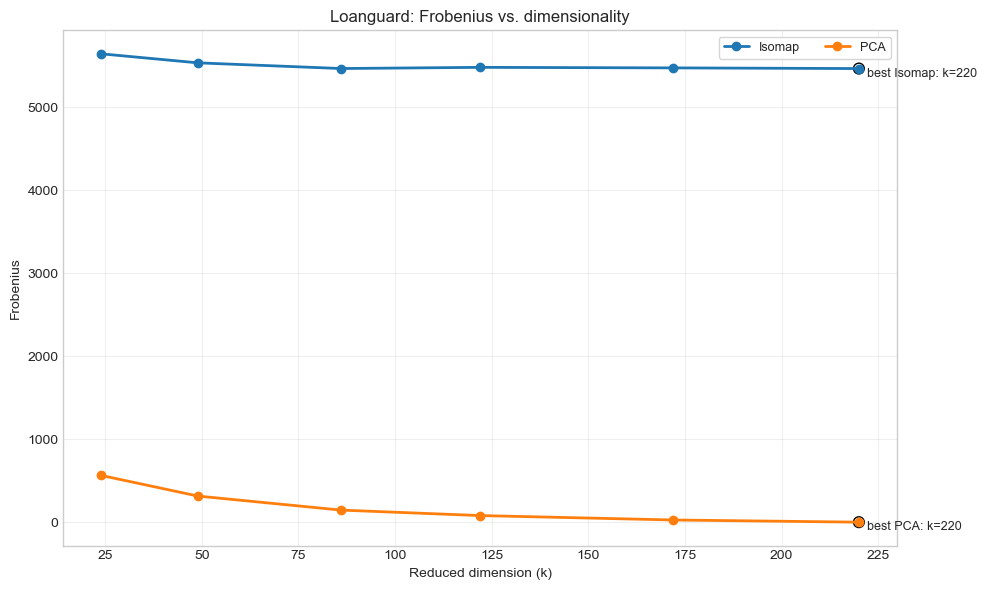

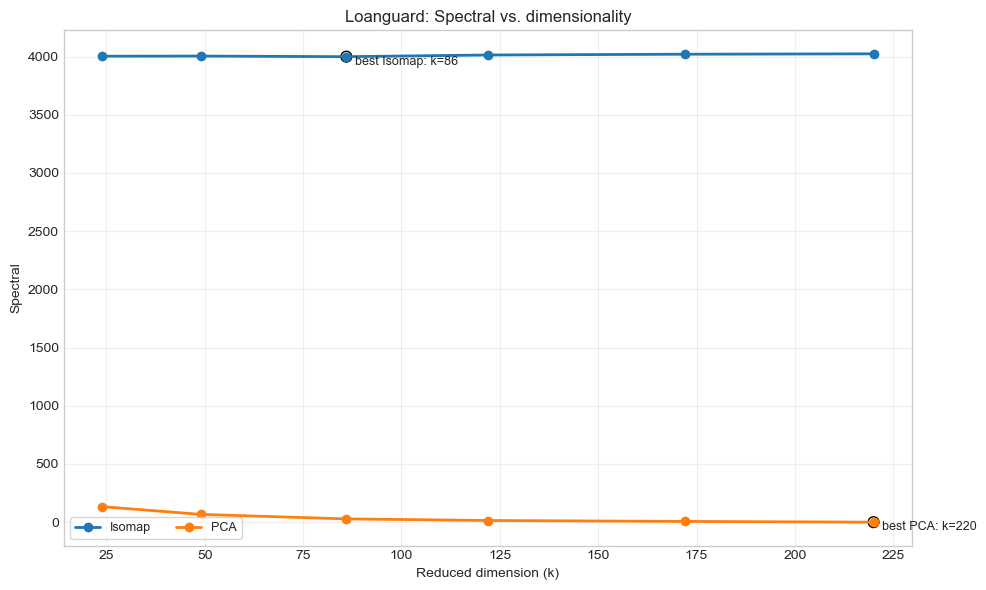

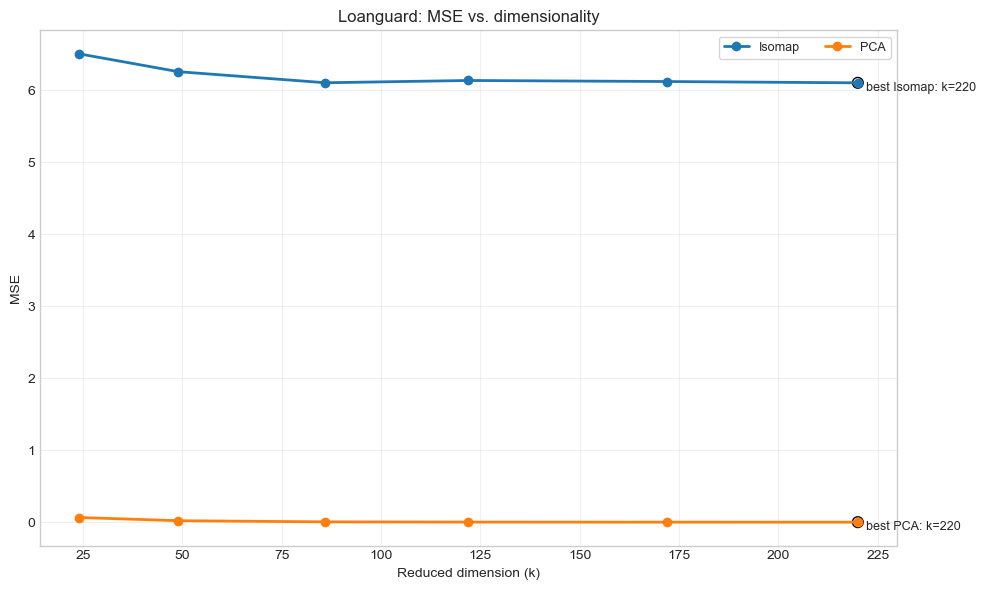

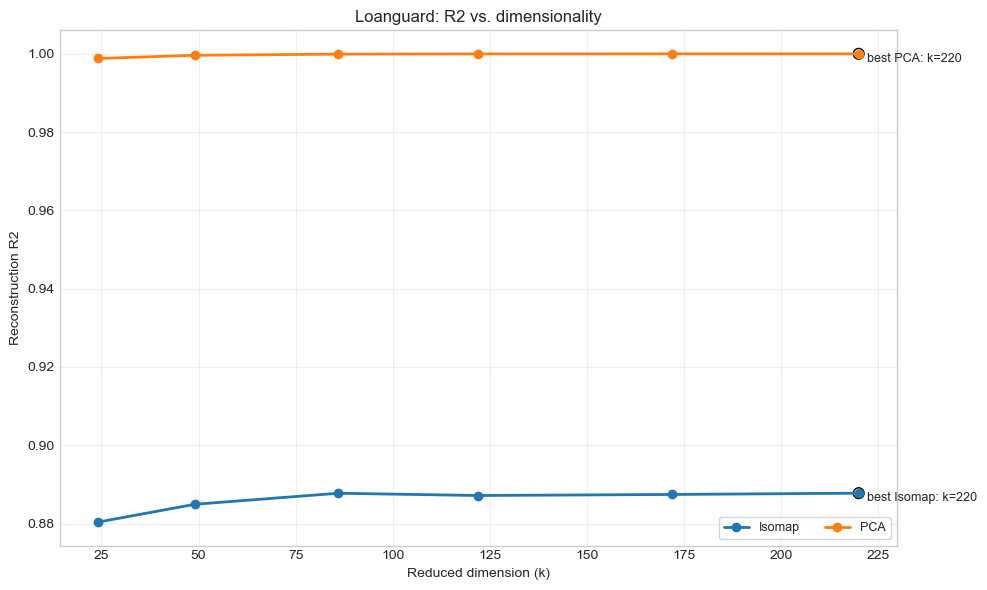

In [18]:
dr.plot_metric_trends_df(df_scores, title_prefix="Loanguard: ")

> Based on the result, PCA performed better than Isomap, reducing the dimensions from 245 to 24, with an R2 score of 0.998809.

In [19]:
complete_preprocessing_pipeline = make_pipeline(preprocessing, PCA(n_components=24, svd_solver='randomized', random_state=37))
complete_preprocessing_pipeline

,steps,"[('columntransformer', ...), ('pca', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Comparision and Justification for preprocessing Techniques

In [20]:
rc = RepCompare()
Z_pca = complete_preprocessing_pipeline.fit_transform(data_train)

In [21]:
Z_pca.shape

(230633, 24)

In [22]:
metrics = rc.evaluate(processed_data, Z_pca, complete_preprocessing_pipeline)
pp(metrics)

{'RV': 1.000000238418579,
 'DistanceCorr': 0.9998961080753006,
 'ReconstructionR2': 0.9987787432157293}


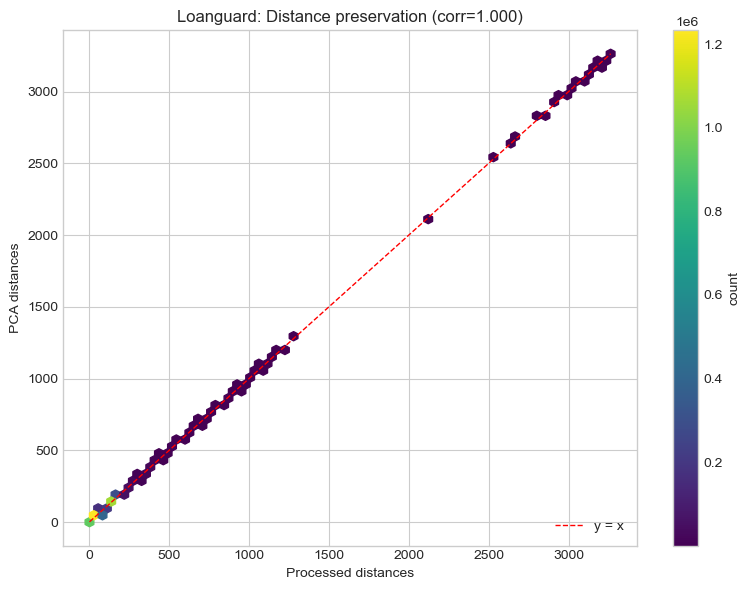

In [23]:
rc.plot_distance_preservation(processed_data, Z_pca, title_prefix="Loanguard: ")

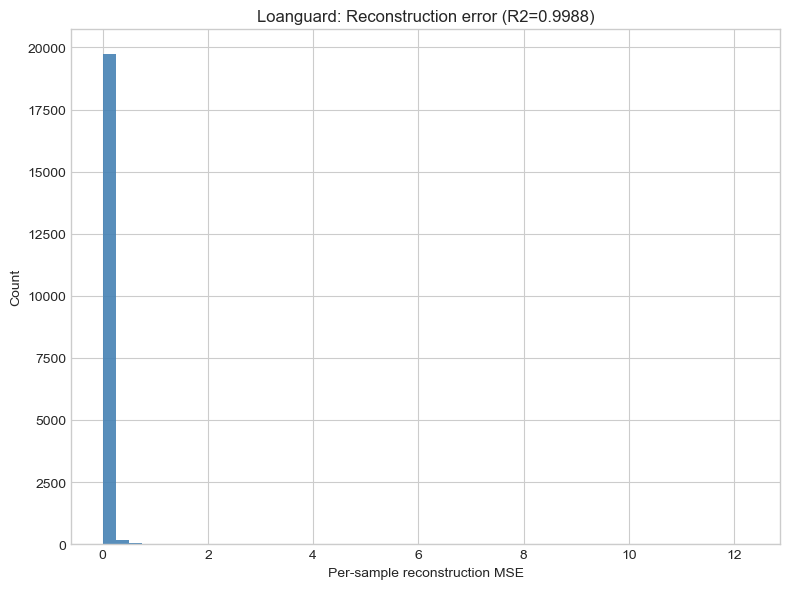

In [24]:
rc.plot_reconstruction_residuals(processed_data, complete_preprocessing_pipeline, title_prefix="Loanguard: ")

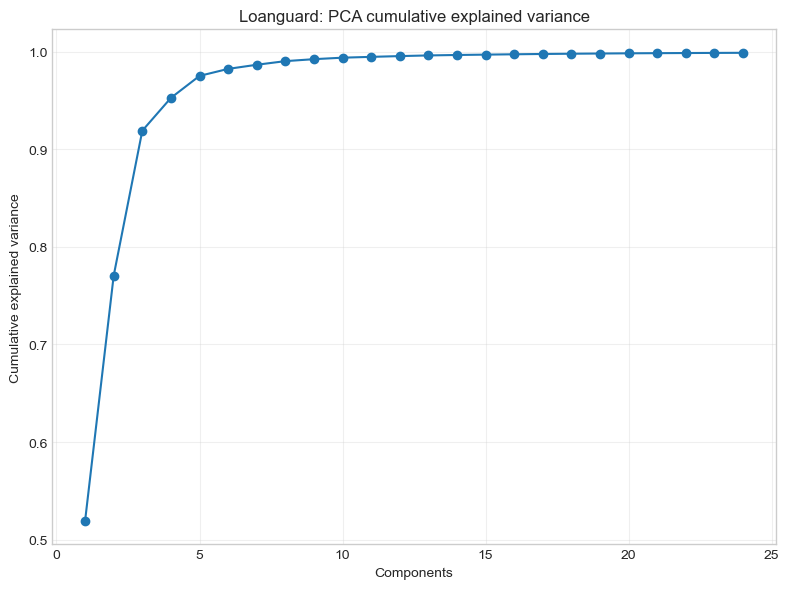

In [25]:
rc.plot_explained_variance(complete_preprocessing_pipeline, title_prefix="Loanguard: ")